# Task 2 — MNIST Neural Network Design-Space Exploration

## 1. What is the main idea of Task 2?

Task 2 continues Task 1.

The main idea is to explore different neural-network architectures for the MNIST handwritten-digit classification problem.

Instead of creating only one fixed neural network, I created a **parameterized neural network** where I can change:

- `n` = number of hidden layers
- `m` = number of neurons in each hidden layer

For every architecture, I:

1. Create the neural network.
2. Train it using the same training conditions.
3. Test it on MNIST.
4. Calculate the accuracy.
5. Calculate the accuracy drop, which is effectively the classification error:
   `accuracy_drop = 100 - accuracy`
6. Count the number of trainable parameters.
7. Store the results.
8. Plot parameter count against accuracy drop.

The final goal is to study the trade-off between:

> **Network complexity / cost** and **classification accuracy**.

---

# 2. Understanding the neural-network architecture

The network starts with MNIST images.

Each MNIST image is:

```text
28 × 28 pixels
```

Therefore, after flattening:

```text
28 × 28 = 784 input values
```

The output has 10 neurons because MNIST contains 10 classes:

```text
0 1 2 3 4 5 6 7 8 9
```

For example:

```text
n = 3
m = [10, 20, 40]
```

means the network is:

```text
Input
  784
   ↓
Hidden Layer 1
  10 neurons
   ↓
Hidden Layer 2
  20 neurons
   ↓
Hidden Layer 3
  40 neurons
   ↓
Output
  10 neurons
```

So I can represent the architecture as:

```text
(3, [10, 20, 40])
```

---

# 3. The parameterized neural network

The class is:

```python
class parameterized_nn(nn.Module):
```

This means I am creating my own neural-network class based on PyTorch's `nn.Module`.

The constructor is:

```python
def __init__(self, n, m_array_per_nn, input_size=784, output_size=10):
```

The parameters mean:

- `n`: number of hidden layers
- `m_array_per_nn`: number of neurons in every hidden layer
- `input_size=784`: MNIST input size
- `output_size=10`: number of MNIST classes

For example:

```python
parameterized_nn(3, [10, 20, 40])
```

creates:

```text
784 → 10 → 20 → 40 → 10
```

---

# 4. Why do I use a loop to create the layers?

Instead of manually writing:

```python
self.layer1 = nn.Linear(784, 10)
self.layer2 = nn.Linear(10, 20)
self.layer3 = nn.Linear(20, 40)
```

I use:

```python
for i in range(n):
    layers_array.append(
        nn.Linear(layer_in_size, m_array_per_nn[i])
    )
    layer_in_size = m_array_per_nn[i]
```

This makes the network flexible.

If:

```python
n = 2
m = [10, 20]
```

the network becomes:

```text
784 → 10 → 20 → 10
```

If:

```python
n = 4
m = [10, 20, 40, 80]
```

the network becomes:

```text
784 → 10 → 20 → 40 → 80 → 10
```

Therefore, the same class can represent many different architectures.

---

# 5. What is `ModuleList`?

I use:

```python
self.hidden_layers = nn.ModuleList(layers_array)
```

`ModuleList` is a PyTorch container that stores multiple neural-network layers.

It is important because PyTorch then knows that these layers belong to the model and that their parameters need to be trained.

For example, if I have:

```python
layers_array = [
    nn.Linear(784, 10),
    nn.Linear(10, 20),
    nn.Linear(20, 40)
]
```

`ModuleList` stores these layers as part of the model.

---

# 6. The `forward()` function

The `forward()` function describes what happens when data passes through the neural network.

```python
def forward(self, x):
```

First, the image is flattened:

```python
x = x.view(x.size(0), -1)
```

The original batch might look like:

```text
64 × 1 × 28 × 28
```

After flattening:

```text
64 × 784
```

Then every hidden layer is applied:

```python
for layer in self.hidden_layers:
    x = torch.relu(layer(x))
```

Each layer performs approximately:

```text
Wx + b
```

and then ReLU is applied.

ReLU is:

```text
ReLU(x) = max(0, x)
```

So:

```text
-5 → 0
-2 → 0
 0 → 0
 3 → 3
 7 → 7
```

Finally:

```python
return self.output_layer(x)
```

produces 10 output values, one for each digit class.

---

# 7. What is the bounded design space?

I define:

```python
n_array = [1, 2, 3, 4, 5]
```

This means I want to explore networks with:

```text
1 hidden layer
2 hidden layers
3 hidden layers
4 hidden layers
5 hidden layers
```

Then I define possible neuron configurations:

```python
m_array = [
    [10],
    [10, 20],
    [10, 20, 40],
    [10, 20, 40, 80],
    [10, 20, 40, 80, 160],
    [10, 20, 40, 80, 160, 200]
]
```

This defines the bounded design space that I want to explore.

---

# 8. Why can duplicate architectures happen?

This is an important part of the code.

Before training, I force the length of `m` to match `n`.

I use:

```python
if len(m) > n:
    m = m[:n]

elif len(m) < n:
    m = list(m) + [m[-1]] * (n - len(m))
```

The purpose is:

```text
len(m) = n
```

because I need exactly one neuron count for every hidden layer.

---

## Example 1 — `m` is longer than `n`

Suppose:

```python
n = 1
m = [10, 20]
```

There is only one hidden layer, so I only need one value in `m`.

Therefore:

```python
m = m[:1]
```

gives:

```python
m = [10]
```

So:

```text
n = 1
m = [10, 20]
```

becomes:

```text
n = 1
m = [10]
```

But I might already have encountered:

```text
n = 1
m = [10]
```

from the beginning.

Therefore, these two configurations produce exactly the same neural network:

```text
784 → 10 → 10
```

So training both would be unnecessary.

---

## Example 2 — `m` is shorter than `n`

Suppose:

```python
n = 2
m = [10]
```

I need two hidden-layer sizes, but I only have one.

I use:

```python
m[-1]
```

`-1` means the last element of the list.

For:

```python
m = [10]
```

we have:

```python
m[-1] = 10
```

Then:

```python
[n - len(m)]
```

is:

```text
2 - 1 = 1
```

Therefore:

```python
[m[-1]] * 1
```

becomes:

```python
[10]
```

So:

```python
m = [10] + [10]
```

giving:

```python
m = [10, 10]
```

The network becomes:

```text
784 → 10 → 10 → 10
```

---

# 9. Why do I use `seen`?

I create:

```python
seen = set()
```

A Python `set` is a collection that stores unique values.

For example:

```python
seen = set()

seen.add(10)
seen.add(20)
seen.add(10)
```

The result is effectively:

```text
{10, 20}
```

The second `10` is not stored again.

I use this property to remember which neural-network architectures I have already trained.

---

# 10. Why do I use `tuple(m)`?

The architecture is represented by:

```python
cfg = (n, tuple(m))
```

For example:

```python
n = 3
m = [10, 20, 40]
```

becomes:

```python
cfg = (3, (10, 20, 40))
```

I use a tuple because I want to put the architecture inside a `set`.

Python lists are mutable, so they cannot be used as set elements.

A tuple is immutable, so it can be used.

---

# 11. How does duplicate detection work?

The code is:

```python
cfg = (n, tuple(m))

if cfg in seen:
    continue

seen.add(cfg)
```

Suppose I first encounter:

```text
n = 1
m = [10]
```

Then:

```text
cfg = (1, (10,))
```

`seen` is initially empty:

```text
seen = {}
```

So:

```python
cfg in seen
```

is:

```text
False
```

Then:

```python
seen.add(cfg)
```

stores the architecture.

Now:

```text
seen = {
    (1, (10,))
}
```

Later I encounter:

```text
n = 1
m = [10, 20]
```

After normalization:

```text
m = [10]
```

Therefore:

```text
cfg = (1, (10,))
```

This already exists in `seen`.

So:

```python
if cfg in seen:
```

is `True`.

Then:

```python
continue
```

means:

> Skip this iteration and go to the next architecture.

Therefore, I do not train the same neural network twice.

---

# 12. What does `continue` mean?

Consider:

```python
for i in range(5):

    if i == 2:
        continue

    print(i)
```

The output is:

```text
0
1
3
4
```

When Python reaches `i == 2`, it skips the rest of that loop iteration.

In my code:

```python
if cfg in seen:
    continue
```

means:

> This architecture has already been trained, so skip it and move to the next architecture.

---

# 13. Training conditions

For every unique architecture I create:

```python
model = parameterized_nn(n, m)
```

Then I use the same:

```python
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)
epochs = 5
```

This is important because I want to compare the architectures fairly.

The basic flow is:

```text
Architecture
      ↓
Create model
      ↓
Same optimizer
      ↓
Same learning rate
      ↓
Same number of epochs
      ↓
Train
      ↓
Test
```

---

# 14. What does `CrossEntropyLoss` do?

The network produces 10 output values.

For example, it might produce something conceptually like:

```text
[0.1, 0.2, 0.05, 0.8, 0.1, ...]
```

The correct label might be:

```text
3
```

The loss function measures how different the prediction is from the correct answer.

During training, the objective is to minimize this loss.

---

# 15. What does the optimizer do?

I use:

```python
optimizer = torch.optim.Adam(...)
```

The optimizer updates the network's weights based on the calculated gradients.

The basic idea is:

```text
Forward pass
     ↓
Calculate loss
     ↓
Backward pass
     ↓
Calculate gradients
     ↓
Optimizer updates weights
```

---

# 16. `optimizer.zero_grad()`

I use:

```python
optimizer.zero_grad()
```

before calculating new gradients.

PyTorch normally accumulates gradients, so I clear the old gradients before processing the next batch.

---

# 17. `loss.backward()`

I use:

```python
loss.backward()
```

This performs backpropagation.

It calculates how the loss changes with respect to the trainable parameters.

Conceptually:

```text
∂Loss / ∂Weight
```

for the different weights.

---

# 18. `optimizer.step()`

Then:

```python
optimizer.step()
```

uses the gradients to update the network parameters.

Conceptually:

```text
new weight
=
old weight
-
learning rate × gradient
```

Adam has additional mechanisms that make the update more sophisticated than this simple equation, but this is the basic idea.

---

# 19. Testing the network

After training:

```python
model.eval()
```

puts the model into evaluation mode.

Then:

```python
with torch.no_grad():
```

means I don't need to calculate gradients during testing.

This saves memory and computation.

---

# 20. How do I get the prediction?

The network produces 10 output values.

I use:

```python
predictions = torch.argmax(outputs, dim=1)
```

`argmax` returns the index of the largest value.

For example:

```text
Output:

digit:   0    1    2    3    4
score: 0.1  0.2  0.05  0.8  0.1
```

The largest score is:

```text
0.8
```

at index:

```text
3
```

Therefore the prediction is:

```text
3
```

---

# 21. Calculating accuracy

I compare:

```python
predictions == labels
```

to see which predictions are correct.

Then:

```python
correct += (predictions == labels).sum().item()
```

counts the number of correct predictions.

Finally:

```python
accuracy = 100 * correct / total
```

gives the accuracy percentage.

For example:

```text
Correct predictions = 9800
Total predictions   = 10000
```

then:

```text
Accuracy = 98%
```

---

# 22. Accuracy drop

I calculate:

```python
accuracy_drop = 100 - accuracy
```

For example:

```text
Accuracy      = 98%
Accuracy drop = 2%
```

In this context, `accuracy_drop` is essentially the **classification error rate**.

So a better name could be:

```python
error_rate_array
```

instead of:

```python
accuracy_drop_array
```

because it is calculated as:

```text
100 - accuracy
```

---

# 23. Counting the number of parameters

I define:

```python
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())
```

The purpose is to calculate the total number of trainable parameter values in the network.

For a linear layer:

```text
Linear(input_size, output_size)
```

the number of parameters is:

```text
weights = input_size × output_size
biases  = output_size

total = input_size × output_size + output_size
```

For example:

```text
784 → 10
```

has:

```text
784 × 10 + 10
= 7850 parameters
```

The function adds the parameters from all layers.

---

# 24. What does `numel()` mean?

`numel()` means:

> Number of elements.

For example, a tensor containing:

```text
2 × 3
```

values has:

```text
6 elements
```

Therefore:

```python
tensor.numel()
```

returns:

```text
6
```

For the neural network, I use it to count the number of values stored in each parameter tensor.

---

# 25. Saving the results

I create arrays:

```python
accuracy_array = []
accuracy_drop_array = []
parameter_count_array = []
points_array = []
```

For every architecture, I save:

```python
accuracy_array.append(accuracy)
accuracy_drop_array.append(accuracy_drop)
parameter_count_array.append(count_parameters(model))
points_array.append((n, m))
```

So every architecture gets associated with:

```text
Architecture
     ↓
Parameter count
     ↓
Accuracy
     ↓
Accuracy drop
```

---

# 26. Important Python functions used in the code

## `print()`

Displays information in the terminal.

```python
print("Hello")
```

---

## `len()`

Returns the number of elements.

```python
x = [10, 20, 30]
len(x)
```

returns:

```text
3
```

---

## `range()`

Generates a sequence of numbers.

```python
range(3)
```

gives:

```text
0, 1, 2
```

---

## `list()`

Converts something into a Python list.

```python
list((10, 20))
```

becomes:

```text
[10, 20]
```

---

## `tuple()`

Converts something into a tuple.

```python
tuple([10, 20])
```

becomes:

```text
(10, 20)
```

---

## `set()`

Creates a collection of unique elements.

```python
seen = set()
```

---

## `.add()`

Adds an element to a set.

```python
seen.add(10)
```

---

## `.append()`

Adds an element to the end of a list.

```python
accuracy_array.append(98.2)
```

---

## `sum()`

Adds values together.

```python
sum([10, 20, 30])
```

returns:

```text
60
```

---

## `np.asarray()`

Converts data into a NumPy array.

```python
np.asarray([10, 20, 30])
```

returns a NumPy array.

Remember to import NumPy:

```python
import numpy as np
```

However, NumPy is not really necessary for the current architecture-handling code.

---

# 27. Important PyTorch functions/methods

### `super().__init__()`

Initializes the parent `nn.Module` class.

---

### `nn.Linear()`

Creates a fully connected neural-network layer.

```python
nn.Linear(784, 10)
```

means:

```text
784 inputs → 10 outputs
```

---

### `nn.ModuleList()`

Stores multiple PyTorch layers as part of the model.

---

### `forward()`

Defines the forward path of the neural network.

---

### `.view()`

Reshapes a tensor.

```python
x.view(x.size(0), -1)
```

converts:

```text
batch × 1 × 28 × 28
```

into:

```text
batch × 784
```

---

### `torch.relu()`

Applies the ReLU activation function.

```text
ReLU(x) = max(0,x)
```

---

### `model.train()`

Puts the model into training mode.

---

### `model.eval()`

Puts the model into evaluation mode.

---

### `optimizer.zero_grad()`

Clears old gradients.

---

### `loss.backward()`

Calculates gradients using backpropagation.

---

### `optimizer.step()`

Updates the model parameters.

---

### `torch.no_grad()`

Disables gradient calculation temporarily.

Useful during testing.

---

### `torch.argmax()`

Finds the index of the largest value.

Useful for converting the network's output scores into a predicted class.

---

### `.item()`

Converts a single-value PyTorch tensor into a normal Python number.

---

### `.numel()`

Returns the number of elements in a tensor.

---

# 28. Python nested loops in my code

I have:

```python
for n in n_array:
    for m in m_array:
```

This is a nested loop.

If:

```python
n_array = [1, 2, 3]
```

and:

```python
m_array = [
    [10],
    [10, 20]
]
```

Python explores:

```text
n = 1
    m = [10]
    m = [10, 20]

n = 2
    m = [10]
    m = [10, 20]

n = 3
    m = [10]
    m = [10, 20]
```

So I am effectively exploring combinations of:

```text
number of hidden layers
            ×
hidden-layer neuron configuration
```

This is called **design-space exploration**.

---

# 29. The whole program in simple terms

If I remove all the PyTorch details, my program is basically doing:

```python
architectures = generate_all_architectures()

for architecture in architectures:

    model = create_network(architecture)

    train(model)

    accuracy = test(model)

    error = 100 - accuracy

    cost = count_parameters(model)

    save_results(
        architecture,
        cost,
        error
    )

plot(cost, error)
```

So the complete concept is:

```text
                 Design Space
                     │
                     ↓
          Generate architectures
                     │
                     ↓
             Remove duplicates
                     │
                     ↓
               Create model
                     │
                     ↓
                Train model
                     │
                     ↓
                Test model
                     │
            ┌────────┴────────┐
            ↓                 ↓
       Accuracy         Parameter Count
            │                 │
            ↓                 ↓
      Accuracy Drop          Cost
            │                 │
            └────────┬────────┘
                     ↓
               Scatter Plot
```

---

# 30. One important point about the "Pareto front"

The current code has:

```python
plt.title("pareto optimal front")
```

but it does **not actually calculate the Pareto-optimal front yet**.

It currently plots **all explored architectures**.

For this problem, I have two objectives:

```text
Minimize parameter count
Minimize accuracy drop
```

A design is Pareto-optimal if there is no other design that is:

```text
better or equal in both objectives
```

with at least one objective being strictly better.

Therefore, the next step after the current code is:

```text
All architectures
        ↓
Calculate which architectures are dominated
        ↓
Remove dominated architectures
        ↓
Keep Pareto-optimal architectures
        ↓
Plot the Pareto front
```

That is the part that still needs to be implemented.


Training images: 60000
Test images: 10000

currently exploring model(n= 1,m= [10])
Epoch 1/5 — Loss: 0.6442
Epoch 2/5 — Loss: 0.3352
Epoch 3/5 — Loss: 0.2953
Epoch 4/5 — Loss: 0.2775
Epoch 5/5 — Loss: 0.2670

Final test accuracy for model(n= 1,m= [10]) : 92.51%

accuracy drop for model(n= 1,m= [10]) : 7.49%
parameter count for model(n= 1,m= [10]): 7960

currently exploring model(n= 2,m= [10, 10])
Epoch 1/5 — Loss: 0.8216
Epoch 2/5 — Loss: 0.3412
Epoch 3/5 — Loss: 0.2908
Epoch 4/5 — Loss: 0.2624
Epoch 5/5 — Loss: 0.2447

Final test accuracy for model(n= 2,m= [10, 10]) : 93.27%

accuracy drop for model(n= 2,m= [10, 10]) : 6.73%
parameter count for model(n= 2,m= [10, 10]): 8070

currently exploring model(n= 2,m= [10, 20])
Epoch 1/5 — Loss: 0.6516
Epoch 2/5 — Loss: 0.3002
Epoch 3/5 — Loss: 0.2605
Epoch 4/5 — Loss: 0.2392
Epoch 5/5 — Loss: 0.2253

Final test accuracy for model(n= 2,m= [10, 20]) : 93.81%

accuracy drop for model(n= 2,m= [10, 20]) : 6.19%
parameter count for model(n= 2,m= [10

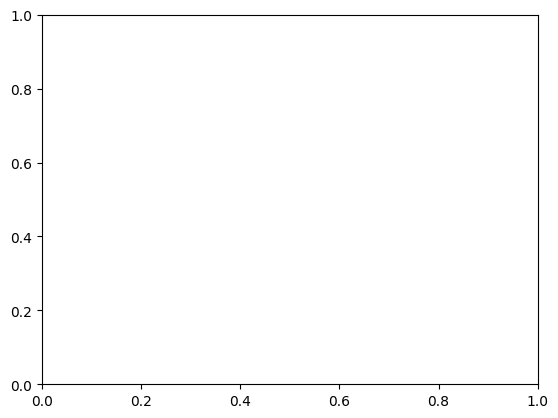

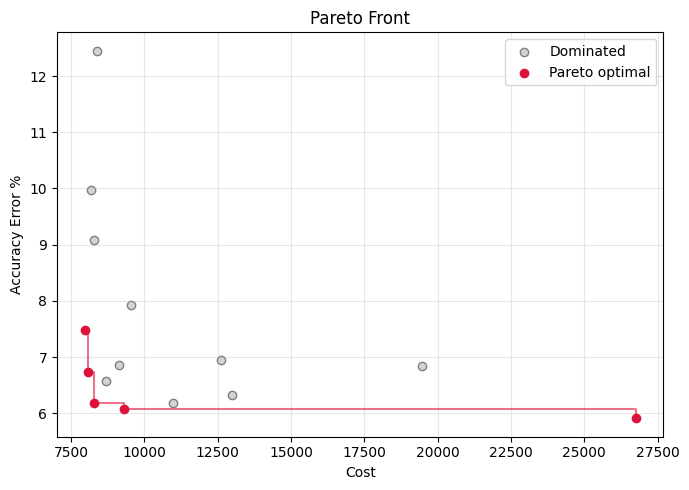

In [7]:
##task 2
#continuing on task 1
#the working code
# ============================================================
# Your first neural network — training on handwritten digits (MNIST)
# ============================================================

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# STEP 1: Get the training images (MNIST downloads automatically)
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor()  # converts each image into numbers PyTorch can use
])

train_data = datasets.MNIST(
    root="./data",       # where to save the downloaded images
    train=True,           # use the training set (60,000 images)
    download=True,        # download it if not already saved
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,           # use the test set (10,000 images) to check accuracy
    download=True,
    transform=transform
)

# DataLoader feeds images to the network in small batches (64 at a time)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Training images: {len(train_data)}")
print(f"Test images: {len(test_data)}")

# ------------------------------------------------------------
# STEP 2: Define the network (same as your slide)
# ------------------------------------------------------------
class parameterized_nn(nn.Module):
    def __init__(self , n , m_array_per_nn , input_size=784 , output_size=10):

      #n is number of hidden layers , m is nodes per hidden layer
        super().__init__()

        m_array_per_nn = np.asarray(m_array_per_nn)

        layers_array = []
        layer_in_size = input_size

        #i wnat a for loop bec n is variable
        for i in range(n):
          layers_array.append(nn.Linear(layer_in_size , m_array_per_nn[i]))
          layer_in_size = m_array_per_nn[i]

        self.hidden_layers = nn.ModuleList(layers_array)
        self.output_layer = nn.Linear(layer_in_size,output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)        # flatten 28x28 image into 784 numbers
        for layer in self.hidden_layers:
          x = torch.relu(layer(x))      # weighted sum + ReLU activation

        return self.output_layer(x)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

##the bounded design space
n_array = [1,2,3,4,5]
m_array = [[10],[10,20],[10,20,40],[10,20,40,80],[10,20,40,80,160],[10,20,40,80,160,200]]
#n_array = [1,2,3]
#m_array = [[10],[10,20],[10,20,40]]

accuracy_array = []
accuracy_drop_array = []
parameter_count_array = []

points_array = []

seen = set()                                   # before the loops

for n in n_array:
  for m in m_array:
    if len(m) > n:
      m = m[:n]
    elif len(m)<n :
      m = list(m) + [m[-1]] * (n - len(m))

    cfg = (n, tuple(m))                        # tuples can go in a set, lists can't
    if cfg in seen:
      continue                                 # already trained this one, skip
    seen.add(cfg)

    model = parameterized_nn(n,m)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ------------------------------------------------------------
# STEP 3: Train the network
# must be the same across trials
# ------------------------------------------------------------
    epochs = 5  # how many times we loop over the entire dataset 100 as the paper
    print(f"\ncurrently exploring model(n= {n},m= {m})")
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            optimizer.zero_grad()             # clear old gradients
            outputs = model(images)           # forward pass
            loss = loss_fn(outputs, labels)   # compute how wrong we are
            loss.backward()                   # backpropagation (compute gradients)
            optimizer.step()                  # gradient descent (update weights)

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")

    # ------------------------------------------------------------
    # STEP 4: Test how well it learned
    # ------------------------------------------------------------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():  # no need to track gradients when just testing
        for images, labels in test_loader:
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)  # pick the highest-scoring digit
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    accuracy_drop = 100 - accuracy

    accuracy_array.append(accuracy)
    accuracy_drop_array.append(accuracy_drop)

    points_array.append((n,m))
    print(f"\nFinal test accuracy for model(n= {n},m= {m}) : {accuracy:.2f}%")
    print(f"\naccuracy drop for model(n= {n},m= {m}) : {accuracy_drop:.2f}%")
    print(f"parameter count for model(n= {n},m= {m}): {count_parameters(model)}")

    parameter_count_array.append(count_parameters(model))

pareto_array = np.column_stack((parameter_count_array,accuracy_drop_array))
print(pareto_array)
#plt.scatter(parameter_count_array, accuracy_drop_array)
print(f"parameter_count_array = {parameter_count_array}")
print(f"accuracy_drop_array = {accuracy_drop_array}")


'''
for i in range(len(parameter_count_array)):
    u , o = points_array[i]

    plt.annotate(
        f"n={u}, m={o}",
        (parameter_count_array[i], accuracy_drop_array[i]),
        xytext=(5, 5),
        textcoords="offset points"
    )
'''


'''
plt.xlabel("cost(parameter count)")
plt.ylabel("accuracy drop")
plt.title("pareto optimal front")
print(model)
plt.show()
'''
#plt.grid()
#print(f"\nmaximum accuracy = {max(accuracy_array)}")
######################################
def pareto_front(points, minimize=(True, True)):
    """Return a boolean mask of non-dominated points.

    points   : (N, 2) array of objective values
    minimize : per-objective flag; True = smaller is better, False = larger is better
    """
    pts = np.asarray(points, dtype=float).copy()
    #print(pts)
    # Flip signs so every objective becomes "minimize"
    for i, m in enumerate(minimize):
        if not m:
            pts[:, i] = -pts[:, i]

    n = len(pts)
    is_optimal = np.ones(n, dtype=bool)
    for i in range(n):
        # Point j dominates i if it is <= in all objectives and < in at least one
        dominated = np.all(pts <= pts[i], axis=1) & np.any(pts < pts[i], axis=1)
        if dominated.any():
            is_optimal[i] = False
    return is_optimal


def plot_pareto(points, minimize=(True, True), labels=("Objective 1", "Objective 2")):
    points = np.asarray(points)
    mask = pareto_front(points, minimize)
    front = points[mask]

    # Sort front by first objective so the line connects neatly
    front = front[np.argsort(front[:, 0])]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(*points[~mask].T, c="lightgray", edgecolor="gray", label="Dominated") #Dominated
    ax.scatter(*front.T, c="crimson", zorder=3, label="Pareto optimal")  #pareto
    ax.step(front[:, 0], front[:, 1], where="post", c="crimson", alpha=0.6)
    for i in range(len(parameter_count_array)):
      u , o = points_array[i]

      plt.annotate(
          f"n={u}, m={o}",
          (parameter_count_array[i], accuracy_drop_array[i]),
          xytext=(5, 5),
          textcoords="offset points"
      )
    ax.set_xlabel(labels[0])
    ax.set_ylabel(labels[1])
    ax.set_title("Pareto Front")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_pareto(pareto_array, minimize=(True, True), labels=("Cost", "Accuracy Error %"))


[[ 7.96560444  5.11045637]
 [ 4.94990596  4.68226222]
 [ 8.72738128  3.72439433]
 [ 7.27631226  6.69748754]
 [ 1.84759613 12.29048058]
 [ 9.78060116  5.15113743]
 [ 7.85025732  3.14726067]
 [ 8.07457875  4.16875306]
 [ 2.15302269  9.86423268]
 [ 5.05347344  5.4491243 ]
 [ 4.33718222  7.87175106]
 [ 9.3408849   1.55014413]
 [ 6.79478608  5.59506882]
 [ 8.40485452  4.73618058]
 [ 4.99072779  5.11620662]
 [ 3.0451485   6.39873742]
 [ 5.99126308  5.44638852]
 [ 1.5743553  13.90937361]
 [ 8.44868055  4.71624786]
 [ 6.68497959  5.02455998]
 [ 7.82278966  6.95930106]
 [ 4.19073371  6.41340055]
 [ 9.73628222  2.51892593]
 [ 9.03809009  4.48177035]
 [ 8.00545147  4.8282926 ]
 [ 2.75174837 11.30688778]
 [ 5.20048903  7.09845904]
 [ 1.39423389 16.88010204]
 [ 2.38860543 12.56804089]
 [ 7.14744058  3.01505986]
 [ 7.7028594   3.63681111]
 [ 9.70758759  2.67038018]
 [ 3.93242822  6.50120139]
 [ 4.33413735  4.5494992 ]
 [ 5.2260023   6.77974349]
 [ 2.70524223  9.05971925]
 [ 2.16929355  9.01338189]
 

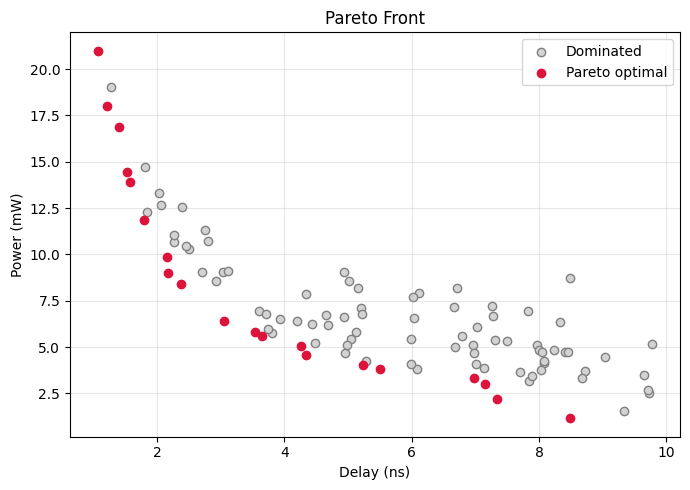

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def pareto_front(points, minimize=(True, True)):
    """Return a boolean mask of non-dominated points.

    points   : (N, 2) array of objective values
    minimize : per-objective flag; True = smaller is better, False = larger is better
    """
    pts = np.asarray(points, dtype=float).copy()
    #print(pts)
    # Flip signs so every objective becomes "minimize"
    for i, m in enumerate(minimize):
        if not m:
            pts[:, i] = -pts[:, i]

    n = len(pts)
    is_optimal = np.ones(n, dtype=bool)
    for i in range(n):
        # Point j dominates i if it is <= in all objectives and < in at least one
        dominated = np.all(pts <= pts[i], axis=1) & np.any(pts < pts[i], axis=1)
        if dominated.any():
            is_optimal[i] = False
    return is_optimal


def plot_pareto(points, minimize=(True, True), labels=("Objective 1", "Objective 2")):
    points = np.asarray(points)
    mask = pareto_front(points, minimize)
    front = points[mask]

    # Sort front by first objective so the line connects neatly
    front = front[np.argsort(front[:, 0])]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(*points[~mask].T, c="lightgray", edgecolor="gray", label="Dominated") #Dominated
    ax.scatter(*front.T, c="crimson", zorder=3, label="Pareto optimal")  #pareto
    #ax.step(front[:, 0], front[:, 1], where="post", c="crimson", alpha=0.6)

    ax.set_xlabel(labels[0])
    ax.set_ylabel(labels[1])
    ax.set_title("Pareto Front")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    rng = np.random.default_rng(42)

    # Example: trade-off between delay and power (both to be minimized)
    delay = rng.uniform(1, 10, 100)
    power = 20 / delay + rng.normal(0, 1.5, 100) + 2
    data = np.column_stack([delay, power])

    plot_pareto(data, minimize=(True, True), labels=("Delay (ns)", "Power (mW)"))

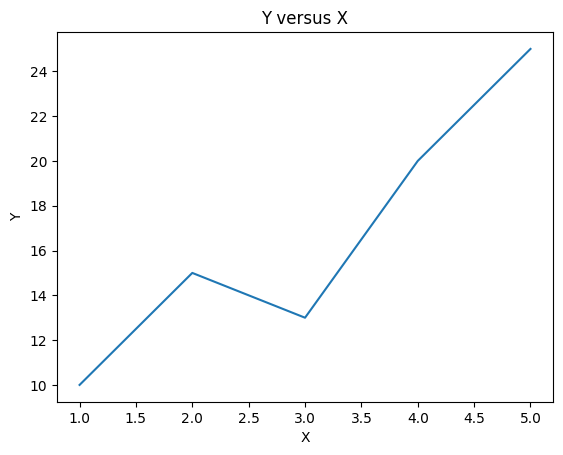

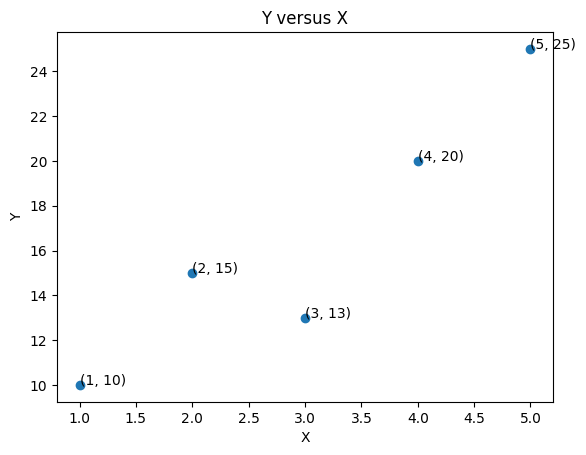

In [ ]:
import matplotlib.pyplot as plt
x = [1, 2, 3, 4, 5]
y = [10, 15, 13, 20, 25]

plt.plot(x, y)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Y versus X")

plt.show()


##for scattered
x = [1, 2, 3, 4, 5]
y = [10, 15, 13, 20, 25]

plt.scatter(x, y)
for i in range(len(x)):
    plt.annotate(
        f"({x[i]}, {y[i]})",
        (x[i], y[i])
    )

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Y versus X")

plt.show()

Training images: 60000
Test images: 10000

currently exploring model(n= 3,m= [10, 20, 40])
Epoch 1/5 — Loss: 0.6393
Epoch 2/5 — Loss: 0.3194
Epoch 3/5 — Loss: 0.2763
Epoch 4/5 — Loss: 0.2538
Epoch 5/5 — Loss: 0.2381

Final test accuracy for model(n= 3,m= [10, 20, 40]) : 92.81%

accuracy drop for model(n= 3,m= [10, 20, 40]) : 7.19%
parameter count for model(n= 3,m= [10, 20, 40]): 9320
parameterized_nn(
  (hidden_layers): ModuleList(
    (0): Linear(in_features=784, out_features=10, bias=True)
    (1): Linear(in_features=10, out_features=20, bias=True)
    (2): Linear(in_features=20, out_features=40, bias=True)
  )
  (output_layer): Linear(in_features=40, out_features=10, bias=True)
)


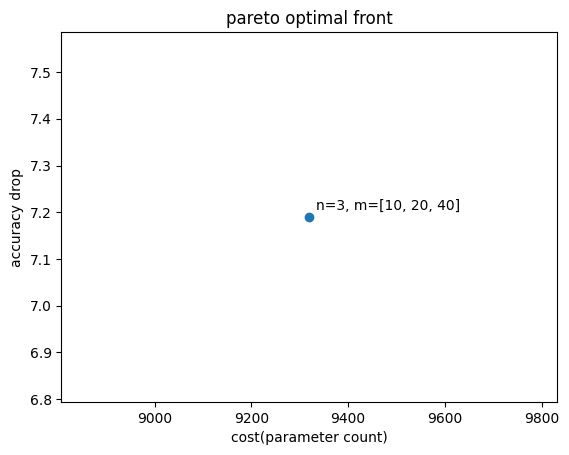

In [ ]:
##########shrouqqqqqqqqqqqqqqqqqqq
##task 2
#continuing on task 1
#the working code
# ============================================================
# Your first neural network — training on handwritten digits (MNIST)
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# STEP 1: Get the training images (MNIST downloads automatically)
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor()  # converts each image into numbers PyTorch can use
])

train_data = datasets.MNIST(
    root="./data",       # where to save the downloaded images
    train=True,           # use the training set (60,000 images)
    download=True,        # download it if not already saved
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,           # use the test set (10,000 images) to check accuracy
    download=True,
    transform=transform
)

# DataLoader feeds images to the network in small batches (64 at a time)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Training images: {len(train_data)}")
print(f"Test images: {len(test_data)}")

# ------------------------------------------------------------
# STEP 2: Define the network (same as your slide)
# ------------------------------------------------------------
class parameterized_nn(nn.Module):
    def __init__(self , n , m_array_per_nn , input_size=784 , output_size=10):

      #n is number of hidden layers , m is nodes per hidden layer
        super().__init__()

        m_array_per_nn = np.asarray(m_array_per_nn)

        layers_array = []
        layer_in_size = input_size

        #i wnat a for loop bec n is variable
        for i in range(n):
          layers_array.append(nn.Linear(layer_in_size , m_array_per_nn[i]))
          layer_in_size = m_array_per_nn[i]

        self.hidden_layers = nn.ModuleList(layers_array)
        self.output_layer = nn.Linear(layer_in_size,output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)        # flatten 28x28 image into 784 numbers
        for layer in self.hidden_layers:
          x = torch.relu(layer(x))      # weighted sum + ReLU activation

        return self.output_layer(x)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

##the bounded design space
#n_array = [1,2,3,4,5]
#m_array = [[10],[10,20],[10,20,40],[10,20,40,80],[10,20,40,80,160],[10,20,40,80,160,200]]
n_array = [3]
m_array = [[10,20,40]]

accuracy_array = []
accuracy_drop_array = []
parameter_count_array = []

points_array = []

for n in n_array:
  for m in m_array:
    model = parameterized_nn(n,m)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ------------------------------------------------------------
# STEP 3: Train the network
# must be the same across trials
# ------------------------------------------------------------
    epochs = 5  # how many times we loop over the entire dataset 100 as the paper
    print(f"\ncurrently exploring model(n= {n},m= {m})")
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            optimizer.zero_grad()             # clear old gradients
            outputs = model(images)           # forward pass
            loss = loss_fn(outputs, labels)   # compute how wrong we are
            loss.backward()                   # backpropagation (compute gradients)
            optimizer.step()                  # gradient descent (update weights)

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")

    # ------------------------------------------------------------
    # STEP 4: Test how well it learned
    # ------------------------------------------------------------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():  # no need to track gradients when just testing
        for images, labels in test_loader:
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)  # pick the highest-scoring digit
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    accuracy_drop = 100 - accuracy

    accuracy_array.append(accuracy)
    accuracy_drop_array.append(accuracy_drop)

    points_array.append((n,m))
    print(f"\nFinal test accuracy for model(n= {n},m= {m}) : {accuracy:.2f}%")
    print(f"\naccuracy drop for model(n= {n},m= {m}) : {accuracy_drop:.2f}%")
    print(f"parameter count for model(n= {n},m= {m}): {count_parameters(model)}")

    parameter_count_array.append(count_parameters(model))

plt.scatter(parameter_count_array, accuracy_drop_array)


for i in range(len(parameter_count_array)):
    u , o = points_array[i]

    plt.annotate(
        f"n={u}, m={o}",
        (parameter_count_array[i], accuracy_drop_array[i]),
        xytext=(5, 5),
        textcoords="offset points"
    )


plt.xlabel("cost(parameter count)")
plt.ylabel("accuracy drop")
plt.title("pareto optimal front")
print(model)
plt.show()
#print(f"\nmaximum accuracy = {max(accuracy_array)}")



Training images: 60000
Test images: 10000


currently exploring model(n= 1,m= [10])
Epoch 1/5 — Loss: 0.6302
Epoch 2/5 — Loss: 0.3044
Epoch 3/5 — Loss: 0.2741
Epoch 4/5 — Loss: 0.2581
Epoch 5/5 — Loss: 0.2489

Final test accuracy for model(n= 1,m= [10]) : 92.74%

accuracy drop for model(n= 1,m= [10]) : 7.26%
parameter count for model(n= 1,m= [10]): 7960


currently exploring model(n= 1,m= [20])
Epoch 1/5 — Loss: 0.5109
Epoch 2/5 — Loss: 0.2727
Epoch 3/5 — Loss: 0.2379
Epoch 4/5 — Loss: 0.2129
Epoch 5/5 — Loss: 0.1932

Final test accuracy for model(n= 1,m= [20]) : 94.54%

accuracy drop for model(n= 1,m= [20]) : 5.46%
parameter count for model(n= 1,m= [20]): 15910


currently exploring model(n= 1,m= [40])
Epoch 1/5 — Loss: 0.4460
Epoch 2/5 — Loss: 0.2217
Epoch 3/5 — Loss: 0.1702
Epoch 4/5 — Loss: 0.1415
Epoch 5/5 — Loss: 0.1220

Final test accuracy for model(n= 1,m= [40]) : 96.33%

accuracy drop for model(n= 1,m= [40]) : 3.67%
parameter count for model(n= 1,m= [40]): 31810


currently ex

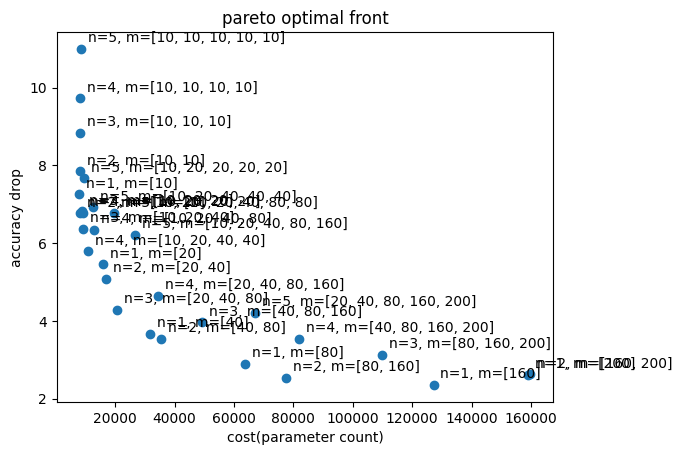

In [ ]:
##trying to have n=1 m=10 and n=1 m=20 .....
#the working code
# ============================================================
# Your first neural network — training on handwritten digits (MNIST)
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# STEP 1: Get the training images (MNIST downloads automatically)
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor()  # converts each image into numbers PyTorch can use
])

train_data = datasets.MNIST(
    root="./data",       # where to save the downloaded images
    train=True,           # use the training set (60,000 images)
    download=True,        # download it if not already saved
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,           # use the test set (10,000 images) to check accuracy
    download=True,
    transform=transform
)

# DataLoader feeds images to the network in small batches (64 at a time)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Training images: {len(train_data)}")
print(f"Test images: {len(test_data)}")

# ------------------------------------------------------------
# STEP 2: Define the network (same as your slide)
# ------------------------------------------------------------
class parameterized_nn(nn.Module):
    def __init__(self , n , m_array_per_nn , input_size=784 , output_size=10):

      #n is number of hidden layers , m is nodes per hidden layer
        super().__init__()

        m_array_per_nn = np.asarray(m_array_per_nn)

        layers_array = []
        layer_in_size = input_size

        #i wnat a for loop bec n is variable
        for i in range(n):
          layers_array.append(nn.Linear(layer_in_size , m_array_per_nn[i]))
          layer_in_size = m_array_per_nn[i]

        self.hidden_layers = nn.ModuleList(layers_array)
        self.output_layer = nn.Linear(layer_in_size,output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)        # flatten 28x28 image into 784 numbers
        for layer in self.hidden_layers:
          x = torch.relu(layer(x))      # weighted sum + ReLU activation

        return self.output_layer(x)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

##the bounded design space
n_array = [1,2,3,4,5]
m_array = [[10],[10,20],[10,20,40],[10,20,40,80],[10,20,40,80,160],[10,20,40,80,160,200]]
#n_array = [3]
#m_array = [[10,20,40]]

accuracy_array = []
accuracy_drop_array = []
parameter_count_array = []

points_array = []

seen = set()                                   # sets doesn't allow duplications

for n in n_array:
  for m in m_array:
    #ana momkn ahot kol al configuraions ale ana 3yzaha f array b3d kda a loop 3leh mara wahda bdl mana 3mla nfs al steps marten#
    if len(m) < n:
      m = list(m) + [m[-1]] * (n - len(m))
      cfg = (n, tuple(m))                        # tuples can go in a set, lists can't
      if cfg in seen:
        continue                                 # already trained this one, skip
      seen.add(cfg)

      model = parameterized_nn(n,m)

      loss_fn = nn.CrossEntropyLoss()
      optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

  # ------------------------------------------------------------
  # STEP 3: Train the network
  # must be the same across trials
  # ------------------------------------------------------------
      epochs = 5  # how many times we loop over the entire dataset 100 as the paper
      print(f"\ncurrently exploring model(n= {n},m= {m})")
      for epoch in range(epochs):
          model.train()
          total_loss = 0

          for images, labels in train_loader:
              optimizer.zero_grad()             # clear old gradients
              outputs = model(images)           # forward pass
              loss = loss_fn(outputs, labels)   # compute how wrong we are
              loss.backward()                   # backpropagation (compute gradients)
              optimizer.step()                  # gradient descent (update weights)

              total_loss += loss.item()

          avg_loss = total_loss / len(train_loader)
          print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")

      # ------------------------------------------------------------
      # STEP 4: Test how well it learned
      # ------------------------------------------------------------
      model.eval()
      correct = 0
      total = 0

      with torch.no_grad():  # no need to track gradients when just testing
          for images, labels in test_loader:
              outputs = model(images)
              predictions = torch.argmax(outputs, dim=1)  # pick the highest-scoring digit
              correct += (predictions == labels).sum().item()
              total += labels.size(0)

      accuracy = 100 * correct / total
      accuracy_drop = 100 - accuracy

      accuracy_array.append(accuracy)
      accuracy_drop_array.append(accuracy_drop)

      points_array.append((n,m))
      print(f"\nFinal test accuracy for model(n= {n},m= {m}) : {accuracy:.2f}%")
      print(f"\naccuracy drop for model(n= {n},m= {m}) : {accuracy_drop:.2f}%")
      print(f"parameter count for model(n= {n},m= {m}): {count_parameters(model)}")

      parameter_count_array.append(count_parameters(model))
    elif len(m) > n:
      for b in range(len(m) - n + 1):
        mm = m[b:n+b]
        #m = m[:n]
        #m = m[1:n+1]   # skip the first (smallest) element, then take the next n  ##the other choice that i want to try
        #m = m[2:n+2]   # skip the second element, then take the next n  ##the other choice that i want to try


        cfg = (n, tuple(mm))                        # tuples can go in a set, lists can't
        if cfg in seen:
          continue                                 # already trained this one, skip
        seen.add(cfg)

        model = parameterized_nn(n,mm)

        loss_fn = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # ------------------------------------------------------------
    # STEP 3: Train the network
    # must be the same across trials
    # ------------------------------------------------------------
        epochs = 5  # how many times we loop over the entire dataset 100 as the paper
        print(f"\n\ncurrently exploring model(n= {n},m= {mm})")
        for epoch in range(epochs):
            model.train()
            total_loss = 0

            for images, labels in train_loader:
                optimizer.zero_grad()             # clear old gradients
                outputs = model(images)           # forward pass
                loss = loss_fn(outputs, labels)   # compute how wrong we are
                loss.backward()                   # backpropagation (compute gradients)
                optimizer.step()                  # gradient descent (update weights)

                total_loss += loss.item()

            avg_loss = total_loss / len(train_loader)
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")

        # ------------------------------------------------------------
        # STEP 4: Test how well it learned
        # ------------------------------------------------------------
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():  # no need to track gradients when just testing
            for images, labels in test_loader:
                outputs = model(images)
                predictions = torch.argmax(outputs, dim=1)  # pick the highest-scoring digit
                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        accuracy = 100 * correct / total
        accuracy_drop = 100 - accuracy

        accuracy_array.append(accuracy)
        accuracy_drop_array.append(accuracy_drop)

        points_array.append((n,mm))
        print(f"\nFinal test accuracy for model(n= {n},m= {mm}) : {accuracy:.2f}%")
        print(f"\naccuracy drop for model(n= {n},m= {mm}) : {accuracy_drop:.2f}%")
        print(f"parameter count for model(n= {n},m= {mm}): {count_parameters(model)}")

        parameter_count_array.append(count_parameters(model))

plt.scatter(parameter_count_array, accuracy_drop_array)


for i in range(len(parameter_count_array)):
    u , o = points_array[i]

    plt.annotate(
        f"n={u}, m={o}",
        (parameter_count_array[i], accuracy_drop_array[i]),
        xytext=(5, 5),
        textcoords="offset points"
    )


plt.xlabel("cost(parameter count)")
plt.ylabel("accuracy drop")
plt.title("pareto optimal front")
print(model)
plt.show()
#print(f"\nmaximum accuracy = {max(accuracy_array)}")

